In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
from sklearn.metrics import r2_score

In [2]:
fdir = '/home/users/liujx/bridge_lamb3/das_bhm/'
psds = np.load(f"{fdir}data/extfig9.npz")
das_psd = psds['das_psd']
acc_psd = psds['acc_psd']
das_f = psds['das_f']
acc_f = psds['acc_f']

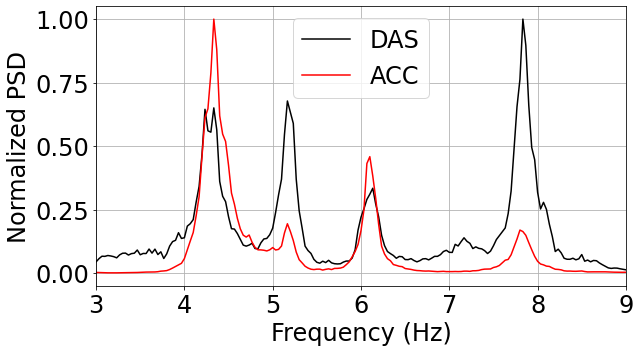

In [3]:
fig,ax = plt.subplots(figsize=(9,5))
plt.plot(das_f,das_psd,'k')
plt.plot(acc_f,acc_psd,'r')
plt.xlabel('Frequency (Hz)',fontsize=24)
plt.ylabel('Normalized PSD',fontsize=24)
plt.xlim([3,9])
plt.grid()
plt.legend(['DAS','ACC'],fontsize=24)
ax.tick_params(axis='both', which='major', labelsize=24)
plt.tight_layout()
plt.savefig(f'{fdir}figs/extfig9.pdf')

In [4]:
fdir = '/home/users/liujx/bridge_lamb3/das_bhm/'
data = np.load(f"{fdir}data/fig6.npz",allow_pickle=True)
t1 = data['t1']
f1 = data['f1']
t2 = data['t2']
f2 = data['f2']
tT = data['tT']
temp = data['temp']

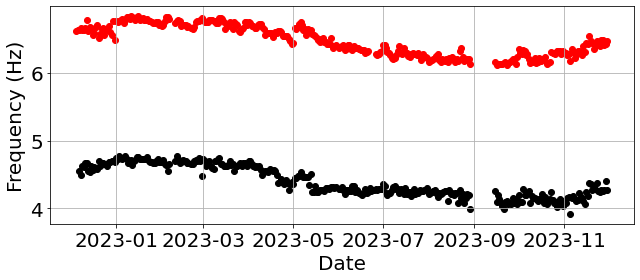

In [5]:
fig,ax = plt.subplots(figsize=(9,4))
plt.scatter(t1,f1,c='k')
plt.scatter(t2,f2,c='r')
plt.xlabel('Date',fontsize=20)
plt.ylabel('Frequency (Hz)',fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=20)
plt.tight_layout()
plt.grid()
plt.savefig(f'{fdir}figs/fig6a.pdf')

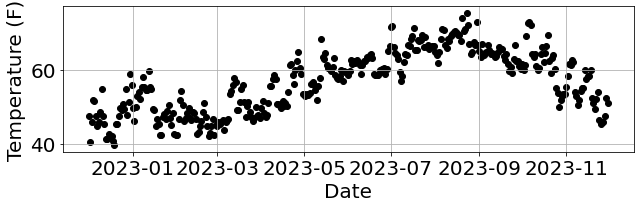

In [6]:
fig,ax = plt.subplots(figsize=(9,3))
plt.scatter(tT,temp,c='k')
plt.xlabel('Date',fontsize=20)
plt.ylabel('Temperature (F)',fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=20)
plt.tight_layout()
plt.grid()
plt.savefig(f'{fdir}figs/fig6b.pdf')

R² value: 0.52


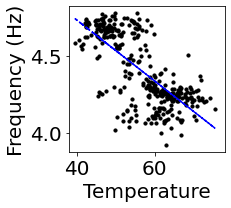

In [11]:
#1st mode
fig,ax = plt.subplots(figsize=(3.5,3))
common, f_idx, temp_idx = np.intersect1d(t1, tT, return_indices=True)
x = np.array(temp[temp_idx]).ravel()
y = np.array(f1[f_idx]).ravel()
plt.scatter(x,y,c='k',s=10)
coeffs = np.polyfit(x, y, deg=1)
fit_line = np.poly1d(coeffs)
plt.plot(x, fit_line(x), 'b--', label='Linear fit')
plt.xlim([38,78])

# R^2 score
r2 = r2_score(y, fit_line(x))
print(f"R² value: {r2:.2f}")
plt.xlabel('Temperature',fontsize=20)
plt.ylabel('Frequency (Hz)',fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=20)
plt.tight_layout()
plt.savefig(f'{fdir}figs/fig6c.pdf')

R² value: 0.55


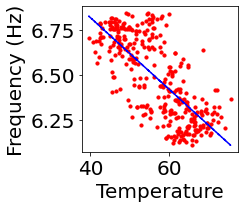

In [13]:
#2nd mode
fig,ax = plt.subplots(figsize=(3.5,3))
common, f_idx, temp_idx = np.intersect1d(t2, tT, return_indices=True)
x = np.array(temp[temp_idx]).ravel()
y = np.array(f2[f_idx]).ravel()
plt.scatter(x,y,c='r',s=10)
coeffs = np.polyfit(x, y, deg=1)
fit_line = np.poly1d(coeffs)
plt.plot(x, fit_line(x), 'b--', label='Linear fit')

# R^2 score
r2 = r2_score(y, fit_line(x))

print(f"R² value: {r2:.2f}")
plt.xlabel('Temperature',fontsize=20)
plt.ylabel('Frequency (Hz)',fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=20)
plt.tight_layout()
# plt.grid()
plt.savefig(f'{fdir}figs/fig6d.pdf')